<a href="https://colab.research.google.com/github/AmaadZiaGit/Linux/blob/main/NVD_Dataset_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data cleaned! Total rows for training: 315670
Model and Vectorizer saved as .pkl files!

--- Classification Report ---
              precision    recall  f1-score   support

    CRITICAL       0.56      0.16      0.25      5910
        HIGH       0.59      0.67      0.63     24734
         LOW       0.36      0.22      0.27      2775
      MEDIUM       0.67      0.72      0.69     29715

    accuracy                           0.62     63134
   macro avg       0.54      0.44      0.46     63134
weighted avg       0.62      0.62      0.61     63134



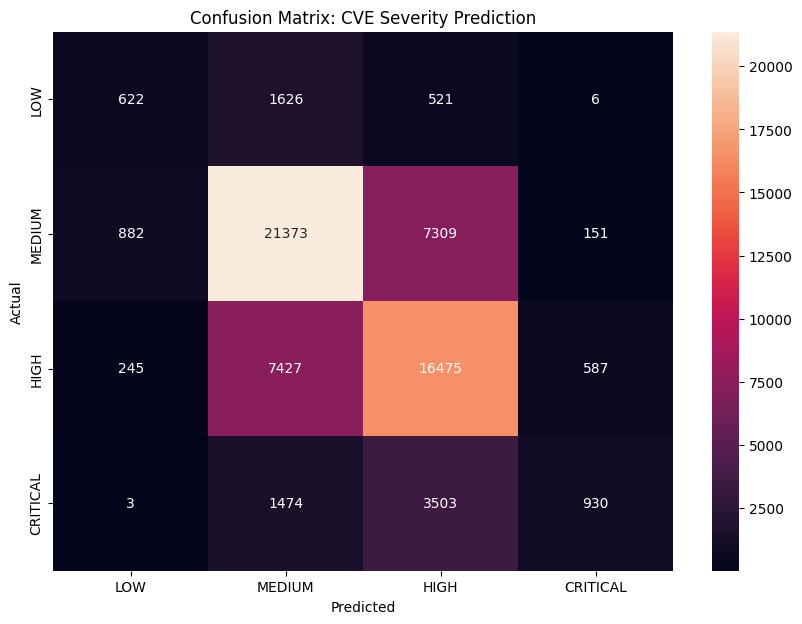

In [6]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('NVD_Cybersecurity_Dataset.csv', on_bad_lines='skip', engine='python')

# 2. CLEAN DATA
# Keeping only the main severity levels and dropping unknowns/nones
valid_severities = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
df = df[df['Severity'].isin(valid_severities)]
df = df.dropna(subset=['Description', 'Severity'])

print(f"Data cleaned! Total rows for training: {len(df)}")

# 3. TEXT PREPROCESSING & SPLITTING
# X is the input text, y is what we want to predict
X = df['Description']
y = df['Severity']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. VECTORIZATION (Turning words into numbers)
# We use TF-IDF to identify "important" security keywords
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 5. MODEL TRAINING
# Naïve Bayes is the most effective starting point for text classification
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 6. SAVE OUTPUTS (REQUIRED FOR SUBMISSION)
# This creates the .pkl files you need to hand in
joblib.dump(model, 'cve_severity_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Model and Vectorizer saved as .pkl files!")

# 7. EVALUATION
# Generating the results for your presentation slides
predictions = model.predict(X_test_tfidf)

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

# 8. VISUALIZATION (For your slides)
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, predictions, labels=valid_severities),
            annot=True, fmt='d', xticklabels=valid_severities, yticklabels=valid_severities)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: CVE Severity Prediction')
plt.show()